In [1]:
#Import libraries
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
from google.colab import drive
import kagglehub
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

#Ignore all warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded=files.upload()
cf=pd.read_excel('index_1.csv.xlsx')
cf

Saving index_1.csv.xlsx to index_1.csv.xlsx


,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte
...,...,...,...,...,...,...
3631,2025-03-23,2025-03-23 10:34:54.894,card,ANON-0000-0000-1158,35.76,Cappuccino
3632,2025-03-23,2025-03-23 14:43:37.362,card,ANON-0000-0000-1315,35.76,Cocoa
3633,2025-03-23,2025-03-23 14:44:16.864,card,ANON-0000-0000-1315,35.76,Cocoa
3634,2025-03-23,2025-03-23 15:47:28.723,card,ANON-0000-0000-1316,25.96,Americano


In [4]:
cf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[ns]
 1   datetime     3636 non-null   datetime64[ns]
 2   cash_type    3636 non-null   object        
 3   card         3547 non-null   object        
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 170.6+ KB


In [5]:
cf.describe()

,date,datetime,money
count,3636,3636,3636.000000
mean,2024-09-30 11:56:02.376237568,2024-10-01 02:35:30.535053568,31.746859
min,2024-03-01 00:00:00,2024-03-01 10:15:50.520000,18.120000
25%,2024-07-03 00:00:00,2024-07-03 16:54:06.084750080,27.920000
50%,2024-10-06 12:00:00,2024-10-07 02:55:12.649500160,32.820000
75%,2025-01-08 00:00:00,2025-01-08 07:55:20.299750144,35.760000
max,2025-03-23 00:00:00,2025-03-23 18:11:38.635000,40.000000
std,NaN,NaN,4.919926


In [6]:
cf.shape

(3636, 6)

In [7]:
cf.isnull().sum()

,0
date,0
datetime,0
cash_type,0
card,89
money,0
coffee_name,0


In [8]:
cf['card'].value_counts()

,count
card,
ANON-0000-0000-0012,129
ANON-0000-0000-0141,108
ANON-0000-0000-1163,77
ANON-0000-0000-0276,69
ANON-0000-0000-0009,67
...,...
ANON-0000-0000-0015,1
ANON-0000-0000-0014,1
ANON-0000-0000-0013,1


In [9]:
cf['datetime'] = pd.to_datetime(cf['datetime'])
cf['date'] = pd.to_datetime(cf['date'])

cf['hour'] = cf['datetime'].dt.hour
cf['day_of_week'] = cf['datetime'].dt.dayofweek
cf['month'] = cf['datetime'].dt.month

In [10]:
daily = cf.groupby('date').agg({
    'money': 'sum',
    'hour': 'mean',
    'datetime': 'count'
}).reset_index()

daily.rename(columns={
    'money': 'total_revenue',
    'datetime': 'transactions_count',
    'hour': 'avg_hour'
}, inplace=True)

daily['day_of_week'] = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
daily['day'] = daily['date'].dt.day

In [11]:
daily = daily.sort_values('date')

daily['lag1'] = daily['total_revenue'].shift(1)
daily['lag7'] = daily['total_revenue'].shift(7)
daily['rolling_mean_7'] = daily['total_revenue'].rolling(7).mean()

daily.dropna(inplace=True)

In [12]:
X = daily.drop(['date', 'total_revenue'], axis=1)
y = daily['total_revenue']

In [13]:
X_train = X[:-30]
X_test = X[-30:]

y_train = y[:-30]
y_test = y[-30:]

In [14]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
models = {
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Neural Network": MLPRegressor(max_iter=1000, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, mae, r2])

In [16]:
results_df = pd.DataFrame(results, columns=["Model", "MSE", "MAE", "R2"])
results_df = results_df.sort_values(by="R2", ascending=False)

print(results_df)

                Model           MSE         MAE        R2
9   Gradient Boosting    426.250031   17.039375  0.987218
3   Linear Regression    434.672050   18.067796  0.986965
4               Ridge    435.252165   18.085627  0.986948
5               Lasso    447.432917   18.461737  0.986583
8       Random Forest    525.575187   18.339224  0.984240
7      Neural Network    570.714434   20.069418  0.982886
6          ElasticNet    579.463139   21.214975  0.982624
10           AdaBoost    724.727251   19.613688  0.978268
2       Decision Tree    899.691640   26.523333  0.973021
1                 KNN  33252.003037  158.085200  0.002872
0                 SVR  54048.324861  196.145514 -0.620748


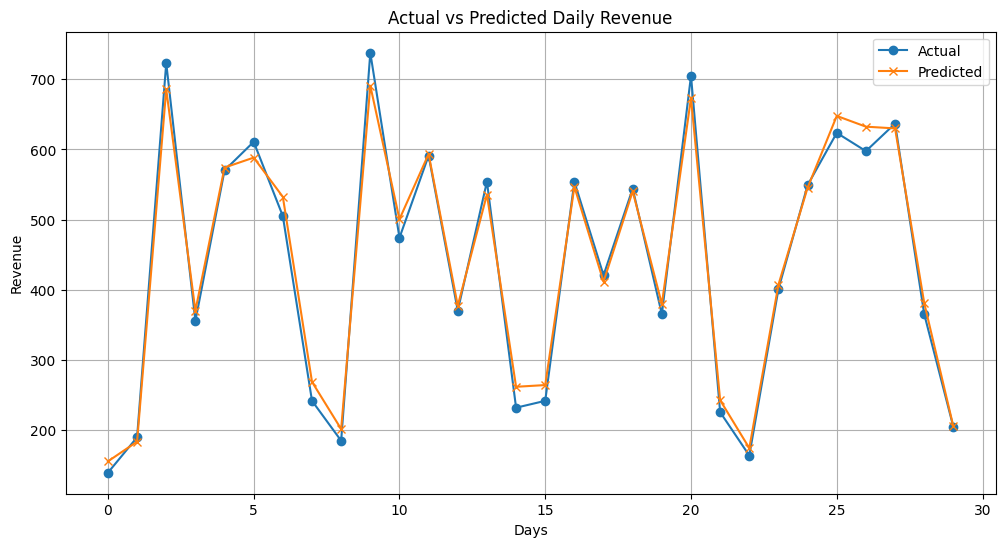

In [17]:
import matplotlib.pyplot as plt

best_model = GradientBoostingRegressor(random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')

plt.title('Actual vs Predicted Daily Revenue')
plt.xlabel('Days')
plt.ylabel('Revenue')
plt.legend()

plt.grid(True)
plt.show()